In [1]:
import gc
import os
from copy import deepcopy
from typing import Any, Dict, List, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from deep_macrofin import (ActivationType, Comparator, OptimizerType, PDEModel,
                           PDEModelTimeStep, SamplingMethod, set_seeds)
from parse_ditella_sol import *

In [2]:
plt.rcParams["font.size"] = 20
plt.rcParams["lines.linewidth"] = 3
plt.rcParams["lines.markersize"] = 10

default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

BASE_DIR = "./models/StochasticVolatility_64bit"
os.makedirs(BASE_DIR, exist_ok=True)

In [3]:
LATEX_VAR_MAPPING = {
    # variables
    r"\iota": "iota",
    r"\hat{e}": "e_hat",
    r"\hat{c}": "c_hat",
    r"\sigma_{x,1}": "sigxtop",
    r"\sigma_{x,2}": "sigxbot",
    r"\sigma_x": "sigx",
    r"\sigma_p": "sigp",
    r"\sigma_\xi": "sigxi",
    r"\sigma_\zeta": "sigzeta",
    r"\tilde{\sigma_n}": "signtilde",
    r"\sigma_n": "sign",
    r"\pi": "signxi",
    r"\sigma_w": "sigw",
    r"\mu_n": "mun",
    r"\mu_x": "mux",
    r"\mu_p": "mup",
    r"\mu_\xi": "muxi",
    r"\mu_\zeta": "muzeta",
    r"\mu_w": "muw",

    # agents
    r"\xi": "xi",
    r"\zeta": "zeta",

    # constants
    r"\bar{\sigma_v}": "sigv_mean",
    r"\sigma_v": "sigv",
    r"\mu_v": "muv",
    r"\sigma": "sigma",
    r"\lambda": "lbd",
    r"\bar{v}": "v_mean",
    r"\rho": "rho",
    r"\gamma": "gamma",
    r"\psi": "psi",
    r"\tau": "tau",
    r"\delta": "delta",
    r"\phi": "phi",
}

PARAMS = {
    "a": 1,
    "sigma": 0.0125,
    "lbd": 1.38,
    "v_mean": 0.25,
    "sigv_mean": -0.17,
    "rho": 0.0665,
    "gamma": 5,
    "psi": 0.5,
    "tau": 1.15,
    "phi": 0.2,

    "A": 53.2,
    "B": -0.8668571428571438,
    "delta": 0.05,
}
STATES = ["x", "v"] 
PROBLEM_DOMAIN = {"x": [0.05, 0.95], "v": [0.05, 0.95]}

VARS_TO_PLOT = ["p", "sigx", "omega", "sigsigp", "signxi", "r"]
PLOT_ARGS = {
    # "p": {"ylabel": r"$p$", "title": r"Price"},
    "sigx": {"ylabel": r"$\sigma_x$", "title": r"Diffusion of Wealth Share"},
    "omega": {"ylabel": r"$\Omega=\xi/\zeta$", "title": r"Ratio of Value Functions ($\Omega=\xi/\zeta$)", "show_legend": True},
    "sigsigp": {"ylabel": r"$\sigma+\sigma_p$", "title": r"Price Return Diffusion", "show_legend": False},
    "signxi": {"ylabel": r"$\pi$", "title": r"Price of Risk", "show_legend": False},
    # "r": {"ylabel": r"$r$", "title": r"Risk-Free Rate"},
}
v_list = [0.1, 0.25, 0.6]
COLORS = ["red", "orange", "blue"]

MODEL_CONFIGS = {
    "Agents": {
        "xi": {"positive": True},
        "zeta": {"positive": True},
    },
    "Endogs": {
        "p": {"positive": True},
        "r": {},
    }
}

TRAINING_CONFIG = {
    "batch_size": 500, 
    "num_outer_iterations": 70, 
    "num_inner_iterations": 5000,
    "sampling_method": SamplingMethod.UniformRandom, 
    "time_batch_size": 1, # can increase time batch size to improve convergence
    "loss_balancing": True
}

In [4]:
set_seeds(0)
model = PDEModelTimeStep("stochastic_volatility", TRAINING_CONFIG, LATEX_VAR_MAPPING)
model.set_state(STATES.copy(), PROBLEM_DOMAIN)
model.add_agents(list(MODEL_CONFIGS["Agents"].keys()), MODEL_CONFIGS["Agents"])
model.add_endogs(list(MODEL_CONFIGS["Endogs"].keys()), MODEL_CONFIGS["Endogs"])
model.add_params(PARAMS)
model.add_equations([
    r"$g &= \frac{1}{2*A} * (p - B) - \delta$", 
    r"$\iota &= A * (g+\delta)^2 + B * (g+\delta)$",
    r"$\mu_v &= \lambda * (\bar{v} - v)$",
    r"$\sigma_v &= \bar{\sigma_v} * \sqrt{v}$",
    r"$\hat{e} &= \rho^{1/\psi} * \xi^{(\psi-1)/\psi}$",
    r"$\hat{c} &= \rho^{1/\psi} * \zeta^{(\psi-1)/\psi}$",
    r"$\sigma_{x,1} &= (1-x) * x * \frac{1-\gamma}{\gamma} * \left( \frac{1}{\xi} * \frac{\partial \xi}{\partial v} - \frac{1}{\zeta} * \frac{\partial \zeta}{\partial v} \right)$",
    r"$\sigma_{x,2} &= 1 - (1-x) * x * \frac{1-\gamma}{\gamma} * \left( \frac{1}{\xi} * \frac{\partial \xi}{\partial x} - \frac{1}{\zeta} * \frac{\partial \zeta}{\partial x} \right)$",
    r"$\sigma_x &= \frac{\sigma_{x,1}}{\sigma_{x,2}} * \sigma_v$",
    r"$\sigma_p &= \frac{1}{p} * \left( \frac{\partial p}{\partial v} * \sigma_v + \frac{\partial p}{\partial x} * \sigma_x \right)$",
    r"$\sigma_\xi &= \frac{1}{\xi} * \left( \frac{\partial \xi}{\partial v} * \sigma_v + \frac{\partial \xi}{\partial x} * \sigma_x \right)$",
    r"$\sigma_\zeta &= \frac{1}{\zeta} * \left( \frac{\partial \zeta}{\partial v} * \sigma_v + \frac{\partial \zeta}{\partial x} * \sigma_x \right)$",
    r"$\sigma_n &= \sigma + \sigma_p + \frac{\sigma_x}{x}$",
    r"$\pi &= \gamma * \sigma_n + (\gamma-1) * \sigma_\xi$",
    r"$\sigma_w &= \frac{\pi}{\gamma} - \frac{\gamma-1}{\gamma} *  \sigma_\zeta$",
    r"$\mu_w &= r + \pi * \sigma_w$",
    r"$\mu_n &= r + \frac{\gamma}{x^2} * (\phi * v)^2 + \pi * \sigma_n$",
    r"$\tilde{\sigma_n} &= \frac{\phi}{x} * v$",
    r"$\mu_x &= x * \left(\mu_n - \hat{e} - \tau + \frac{a-\iota}{p} - r - \pi * (\sigma+\sigma_p) - \frac{\gamma}{x} * (\phi * v)^2 + (\sigma + \sigma_p)^2 - \sigma_n * (\sigma + \sigma_p)\right)$",
     r"$\mu_p &= \frac{1}{p} * \left( \frac{\partial p}{\partial t} + \mu_v * \frac{\partial p}{\partial v} + \mu_x * \frac{\partial p}{\partial x} + \frac{1}{2} * \left( \sigma_v^2 * \frac{\partial^2 p}{\partial v^2} + 2 * \sigma_v * \sigma_x * \frac{\partial^2 p}{\partial v \partial x} + \sigma_x^2 * \frac{\partial^2 p}{\partial x^2} \right)\right)$",
    r"$\mu_\xi &= \frac{1}{\xi} * \left( \frac{\partial \xi}{\partial t} + \mu_v * \frac{\partial \xi}{\partial v} + \mu_x * \frac{\partial \xi}{\partial x} + \frac{1}{2} * \left( \sigma_v^2 * \frac{\partial^2 \xi}{\partial v^2} + 2 * \sigma_v * \sigma_x * \frac{\partial^2 \xi}{\partial v \partial x} + \sigma_x^2 * \frac{\partial^2 \xi}{\partial x^2} \right)\right)$",
    r"$\mu_\zeta &= \frac{1}{\zeta} * \left( \frac{\partial \zeta}{\partial t} + \mu_v * \frac{\partial \zeta}{\partial v} + \mu_x * \frac{\partial \zeta}{\partial x} + \frac{1}{2} * \left( \sigma_v^2 * \frac{\partial^2 \zeta}{\partial v^2} + 2 * \sigma_v * \sigma_x * \frac{\partial^2 \zeta}{\partial v \partial x} + \sigma_x^2 * \frac{\partial^2 \zeta}{\partial x^2} \right)\right)$",
    "omega=xi/zeta", 
    "sigsigp=sigma+sigp",
])
model.add_endog_equation(r"$a - \iota &= p * (\hat{e} * x + \hat{c} * (1-x))$")
model.add_endog_equation(r"$\sigma + \sigma_p &= \sigma_n * x + \sigma_w * (1-x)$")
model.add_endog_equation(r"$\frac{a-\iota}{p} + g + \mu_p + \sigma * \sigma_p - r &= (\sigma + \sigma_p) * \pi + \gamma * \frac{1}{x} * (\phi * v)^2$")
model.add_hjb_equation(r"$\frac{\hat{e}^{1-\psi}}{1-\psi} * \rho * \xi^{\psi-1} + \frac{\tau}{1-\gamma} * \left(\left(\frac{\zeta}{\xi} \right)^{1-\gamma}-1 \right) + \mu_n - \hat{e} + \mu_\xi - \frac{\gamma}{2} * \left( \sigma_n^2 + \sigma_\xi^2 - 2 * \frac{1-\gamma}{\gamma} * \sigma_n * \sigma_\xi + \tilde{\sigma_n}^2 \right) - \frac{\rho}{1-\psi}$")
model.add_hjb_equation(r"$\frac{\hat{c}^{1-\psi}}{1-\psi} * \rho * \zeta^{\psi-1} + \mu_w - \hat{c} + \mu_\zeta - \frac{\gamma}{2} * \left( \sigma_w^2 + \sigma_\zeta^2 - 2 * \frac{1-\gamma}{\gamma} * \sigma_w * \sigma_\zeta \right) - \frac{\rho}{1-\psi}$")
if not os.path.exists(os.path.join(BASE_DIR, f"model.pt")):
    model.train_model(BASE_DIR, "model.pt", full_log=True, variables_to_track=["e_hat", "c_hat"])
model.load_model(torch.load(os.path.join(BASE_DIR, "model_best.pt"), weights_only=False))

Model loaded


In [5]:
def compute_func(pde_model: Union[PDEModel, PDEModelTimeStep], v_list, vars_to_plot):
    N = 100
    res_dict = {}
    for v in v_list:
        SV = torch.zeros((N, 3), device=pde_model.device)
        SV[:, 0] = torch.linspace(PROBLEM_DOMAIN["x"][0], PROBLEM_DOMAIN["x"][1], N)
        SV[:, 1] = torch.ones((N,)) * v
        x_plot = SV[:, 0].detach().cpu().numpy().reshape(-1)
        for i, sv_name in enumerate(pde_model.state_variables):
            pde_model.variable_val_dict[sv_name] = SV[:, i:i+1]
        pde_model.update_variables(SV)
        res_dict["x_plot"] = x_plot
        for var in vars_to_plot:
            res_dict[f"{var}_{v}"] = pde_model.variable_val_dict[var].detach().cpu().numpy().reshape(-1)
    return res_dict

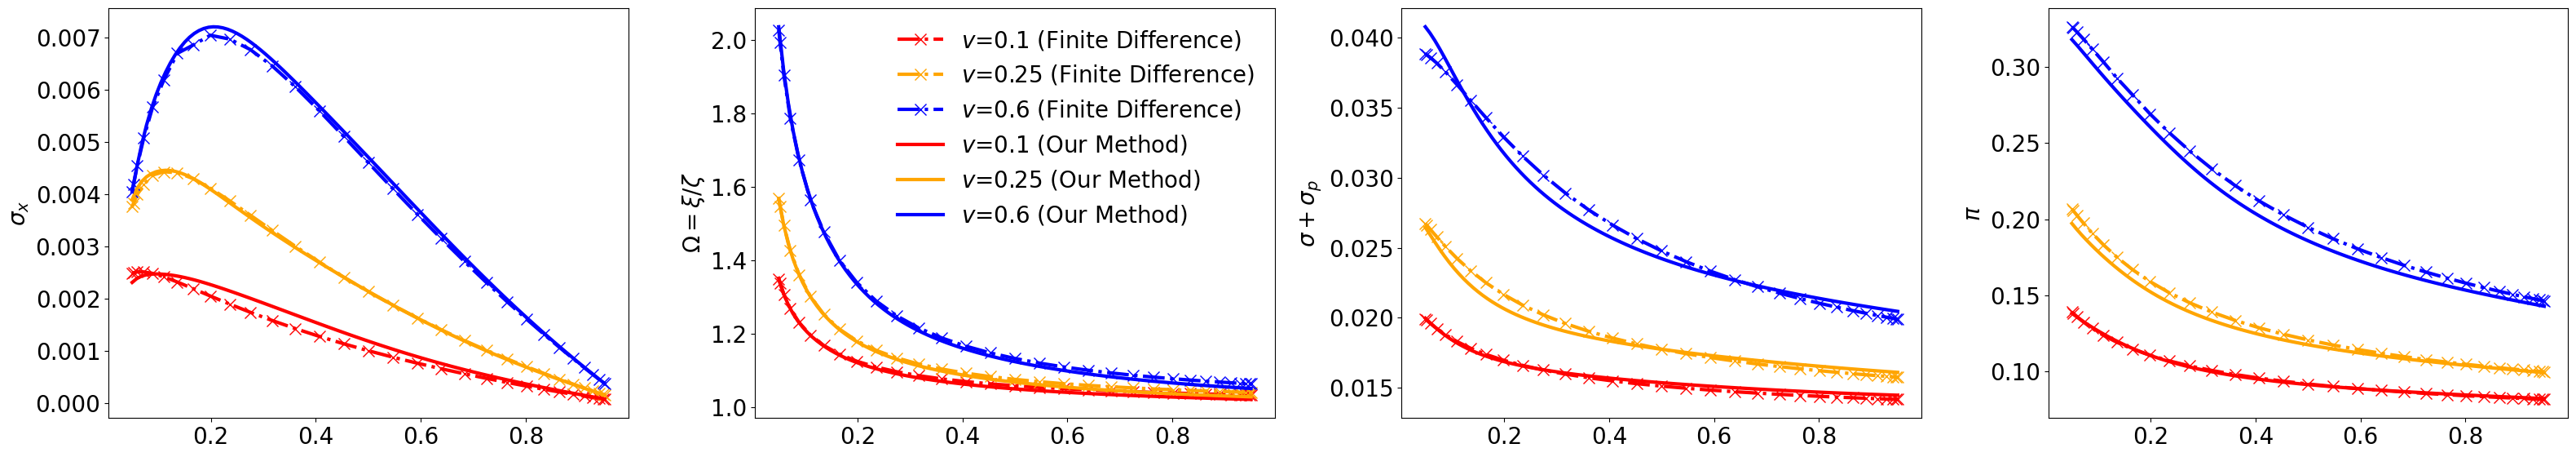

In [6]:
final_plot_dicts = {}
final_plot_dicts["fd"] = ditella_res_dict
final_plot_dicts["timestep_lb"] = compute_func(model, v_list, VARS_TO_PLOT)
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(32, 6))
for i, (func_name, plot_arg) in enumerate(PLOT_ARGS.items()):
    for k, l, ls, marker in [("fd", "Finite Difference", "-.", "x"), ("timestep_lb", "Our Method", "-", "")]:
        res_dict = final_plot_dicts[k].copy()
        x_plot = res_dict.pop("x_plot")
        for j in range(len(v_list)):
            v = v_list[j]
            color = COLORS[j]
            y_vals = res_dict[f"{func_name}_{v}"]
            ax[i].plot(x_plot, y_vals, label=r"$v$={ii} ({l})".format(ii=round(v,2), l=l), linestyle=ls, color=color, marker=marker)
    ax[i].set_xlabel("", fontsize=20)
    ax[i].set_ylabel(plot_arg["ylabel"], fontsize=20)
    # ax.set_title(plot_arg["title"])
    if plot_arg.get("show_legend", False):
        ax[i].legend(loc="upper right", frameon=False, fontsize=20)
plt.tight_layout()
plt.show()